# Tc Human Annotation Visualisation

Comparison of pipeline-extracted critical temperature (Tc) values against human annotations.

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Project style
SRC_DIR = str(Path().resolve().parents[2] / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
from llm_synthesis.utils.style_utils import set_style, get_palette
set_style("manuscript")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": False,
})
sns.set_style("white")

PAL = get_palette()
C_BLUE    = PAL[2]
C_ORANGE  = PAL[4]
C_PURPLE  = PAL[12]
C_PINK    = PAL[0]
C_LBLUE   = PAL[3]
C_LPURPLE = PAL[13]
C_GREY    = PAL[8]
C_DGREY   = PAL[10]
C_BLACK   = PAL[11]
C_LAVENDER = PAL[1]

print("Style loaded")

Style loaded


## Data Loading & Preparation

In [3]:
DATA_PATH = Path.home() / "Downloads" / "tc_master_snippet_human_annotation.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"Loaded: {len(df)} rows, {df.columns.size} columns")

# --- Parse human annotation columns ---
# "Not written" = human confirmed no Tc in text for this material
# "Not in plot" = human confirmed material is not in any figure
# Numeric string = human-annotated Tc value
# NaN = not annotated

# Keep raw strings for FP/FN logic, create numeric versions for plotting
df["Tc_text_human_raw"] = df["Tc_text human "].astype(str).str.strip()
df["Tc_human_raw"] = df["Tc_human"].astype(str).str.strip()

df["Tc_text_human"] = pd.to_numeric(df["Tc_text human "], errors="coerce")
df["Tc_human_num"] = pd.to_numeric(df["Tc_human"], errors="coerce")

# Boolean flags: human explicitly says "not there"
df["text_human_not_written"] = df["Tc_text_human_raw"].str.lower().str.contains("not written", na=False)
df["plot_human_not_in_plot"] = df["Tc_human_raw"].str.lower().str.contains("not in plot", na=False)

# Create tc_text_first: first non-null of tc_text, tc_text_onset, tc_text_zero
df["tc_text_first"] = df["tc_text"].fillna(df["tc_text_onset"]).fillna(df["tc_text_zero"])

print(f"\nNon-null counts for key columns:")
for col in ["tc_text_first", "Tc_text_human", "Tc_human_num",
            "tc_vlm_orig", "tc_vlm_orig_onset", "tc_vlm_orig_zero",
            "tc_vlm_snip", "tc_vlm_snip_onset", "tc_vlm_snip_zero"]:
    print(f"  {col:25s}: {df[col].notna().sum()}")

print(f"\nHuman 'Not written' count: {df['text_human_not_written'].sum()}")
print(f"Human 'Not in plot' count: {df['plot_human_not_in_plot'].sum()}")

df.head(3)

Loaded: 117 rows, 27 columns

Non-null counts for key columns:
  tc_text_first            : 48
  Tc_text_human            : 57
  Tc_human_num             : 62
  tc_vlm_orig              : 64
  tc_vlm_orig_onset        : 64
  tc_vlm_orig_zero         : 64
  tc_vlm_snip              : 67
  tc_vlm_snip_onset        : 67
  tc_vlm_snip_zero         : 67

Human 'Not written' count: 43
Human 'Not in plot' count: 39


,paper_id,year,material,material_normalized,condition,is_superconductor,tc_text,tc_text_onset,tc_text_zero,tc_text_source,...,has_text_tc,has_vlm_tc_orig,has_vlm_tc_snip,Tc_text_human_raw,Tc_human_raw,Tc_text_human,Tc_human_num,text_human_not_written,plot_human_not_in_plot,tc_text_first
0,0904.0824_0904.0824v4,2009,Fe1.03(Te0.63Se0.37),Fe1.03(Te0.63Se0.37),"single-crystal, y=0.03",1.0,NaN,14.8,NaN,NaN,...,False,False,False,14.8,14,14.8,14.0,False,False,14.8
1,0904.0824_0904.0824v4,2009,Fe1.11(Te0.64Se0.36),Fe1.11(Te0.64Se0.36),"single-crystal, y=0.11",1.0,NaN,11.6,NaN,NaN,...,False,False,False,11.6,8,11.6,8.0,False,False,11.6
2,0904.0824_0904.0824v4,2009,"Fe(Te, Se)","Fe(Te, Se)","partial Te substitution for Se, ambient",1.0,14.0,NaN,NaN,NaN,...,True,False,False,Not written,Not in plot,NaN,NaN,True,True,14.0


## Helper Function

In [5]:
def parity_plot(x, y, xlabel, ylabel, title, ax,
                color=None, fp_mask=None, fn_mask=None, fp_vals=None, fn_vals=None):
    """
    Parity plot with identity line, regression, error metrics,
    and marginal markers for false positives / false negatives.

    Parameters
    ----------
    x, y : pd.Series — pipeline/predicted vs human/reference values (numeric, NaN = missing)
    fp_mask : bool Series — True where pipeline extracted a value but human says "not there"
    fn_mask : bool Series — True where human has a value but pipeline has NaN
    fp_vals : pd.Series — the pipeline values for FP points (plotted along x-axis)
    fn_vals : pd.Series — the human values for FN points (plotted along y-axis)
    """
    if color is None:
        color = C_BLUE

    # True positives: both have numeric values
    tp_mask = x.notna() & y.notna()
    x_tp, y_tp = x[tp_mask].values, y[tp_mask].values
    n_tp = len(x_tp)

    # Count FP / FN
    n_fp = fp_mask.sum() if fp_mask is not None else 0
    n_fn = fn_mask.sum() if fn_mask is not None else 0

    if n_tp < 2:
        ax.text(0.5, 0.5, f"Not enough matched data (n={n_tp})",
                transform=ax.transAxes, ha="center", va="center", fontsize=10)
        ax.set_title(title)
        return

    max_val = max(x_tp.max(), y_tp.max()) * 1.15
    min_val = min(x_tp.min(), y_tp.min())
    pad = (max_val - min_val) * 0.05

    # Identity line
    ax.plot([min_val - pad, max_val], [min_val - pad, max_val],
            "k--", lw=1, alpha=0.5, label="$y = x$")

    # Regression + scatter for true positives
    sns.regplot(x=x_tp, y=y_tp, ci=95, ax=ax,
                scatter_kws={"s": 45, "edgecolors": "k", "linewidths": 0.3,
                             "alpha": 0.8, "zorder": 3, "color": color},
                line_kws={"lw": 1.5, "color": C_PURPLE})

    # False positives: pipeline extracted but human says not there → along x-axis
    if fp_vals is not None and n_fp > 0:
        y_fp_pos = min_val - pad * 1.5
        ax.scatter(fp_vals[fp_mask].values, [y_fp_pos] * n_fp,
                   c=C_ORANGE, marker="v", s=30, alpha=0.8, edgecolors="k",
                   linewidths=0.3, zorder=4, label=f"FP (n={n_fp})")

    # False negatives: human has value but pipeline missed → along y-axis
    if fn_vals is not None and n_fn > 0:
        x_fn_pos = min_val - pad * 1.5
        ax.scatter([x_fn_pos] * n_fn, fn_vals[fn_mask].values,
                   c=C_GREY, marker="<", s=30, alpha=0.8, edgecolors="k",
                   linewidths=0.3, zorder=4, label=f"FN (n={n_fn})")

    # Metrics
    r2 = r2_score(y_tp, x_tp)
    mae = mean_absolute_error(y_tp, x_tp)
    rmse = np.sqrt(mean_squared_error(y_tp, x_tp))
    # MAPE: mean absolute percentage error (relative to reference y)
    nonzero = y_tp != 0
    if nonzero.sum() > 0:
        mape = np.mean(np.abs((x_tp[nonzero] - y_tp[nonzero]) / y_tp[nonzero])) * 100
    else:
        mape = np.nan

    stats_text = (f"$R^2$ = {r2:.3f}\nMAE = {mae:.1f} K\n"
                  f"RMSE = {rmse:.1f} K\nMAPE = {mape:.1f}%\n"
                  f"TP = {n_tp}")
    if n_fp > 0:
        stats_text += f"  FP = {n_fp}"
    if n_fn > 0:
        stats_text += f"  FN = {n_fn}"

    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes, fontsize=8, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    lim_lo = min_val - pad * 3 if (n_fp > 0 or n_fn > 0) else min_val - pad
    ax.set_xlim(lim_lo, max_val)
    ax.set_ylim(lim_lo, max_val)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(fontsize=7, loc="lower right")

---
## 1 · Pipeline Text Extraction vs Human Text Annotation

`tc_text_first` (first non-null of tc_text / tc_text_onset / tc_text_zero) vs `Tc_text human`

- **FP**: pipeline extracted a Tc from text, but human says "Not written" → false detection
- **FN**: human found a Tc in text, but pipeline returned NaN → missed extraction

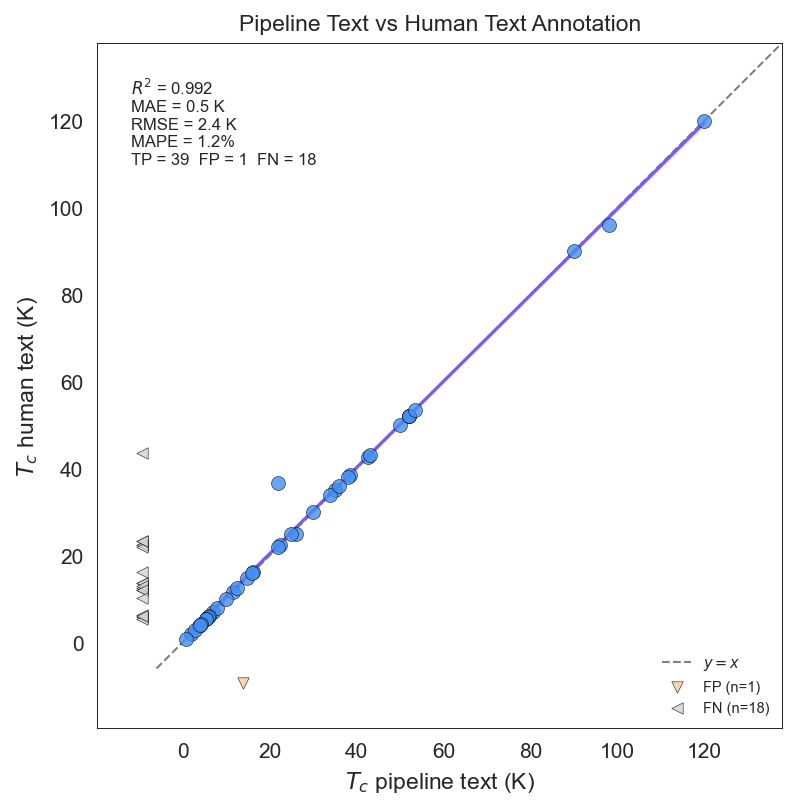


--- Pipeline Text vs Human Text ---
TP (39): Both pipeline and human found a Tc value in the text.
FP (1): Pipeline extracted a Tc from text, but human says 'Not written' — false detection / hallucination.
FN (18): Human found a Tc in the text, but pipeline returned nothing — missed extraction.


In [6]:
# FP: pipeline extracted text Tc but human says "Not written"
fp_text = df["tc_text_first"].notna() & df["text_human_not_written"]
# FN: human has a text Tc value but pipeline missed it
fn_text = df["tc_text_first"].isna() & df["Tc_text_human"].notna()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
parity_plot(
    df["tc_text_first"], df["Tc_text_human"],
    xlabel="$T_c$ pipeline text (K)",
    ylabel="$T_c$ human text (K)",
    title="Pipeline Text vs Human Text Annotation",
    ax=ax, color=C_BLUE,
    fp_mask=fp_text, fp_vals=df["tc_text_first"],
    fn_mask=fn_text, fn_vals=df["Tc_text_human"],
)
plt.tight_layout()
plt.show()

n_tp = (df["tc_text_first"].notna() & df["Tc_text_human"].notna()).sum()
print(f"\n--- Pipeline Text vs Human Text ---")
print(f"TP ({n_tp}): Both pipeline and human found a Tc value in the text.")
print(f"FP ({fp_text.sum()}): Pipeline extracted a Tc from text, but human says 'Not written' — false detection / hallucination.")
print(f"FN ({fn_text.sum()}): Human found a Tc in the text, but pipeline returned nothing — missed extraction.")

---
## 2 · Human Ground-Truth Tc vs Each VLM Extraction

`Tc_human` (from plot) compared separately against each of the six VLM columns.

- **FP**: VLM extracted a value but human says "Not in plot" → false detection
- **FN**: human has a plot Tc but VLM returned NaN → missed extraction

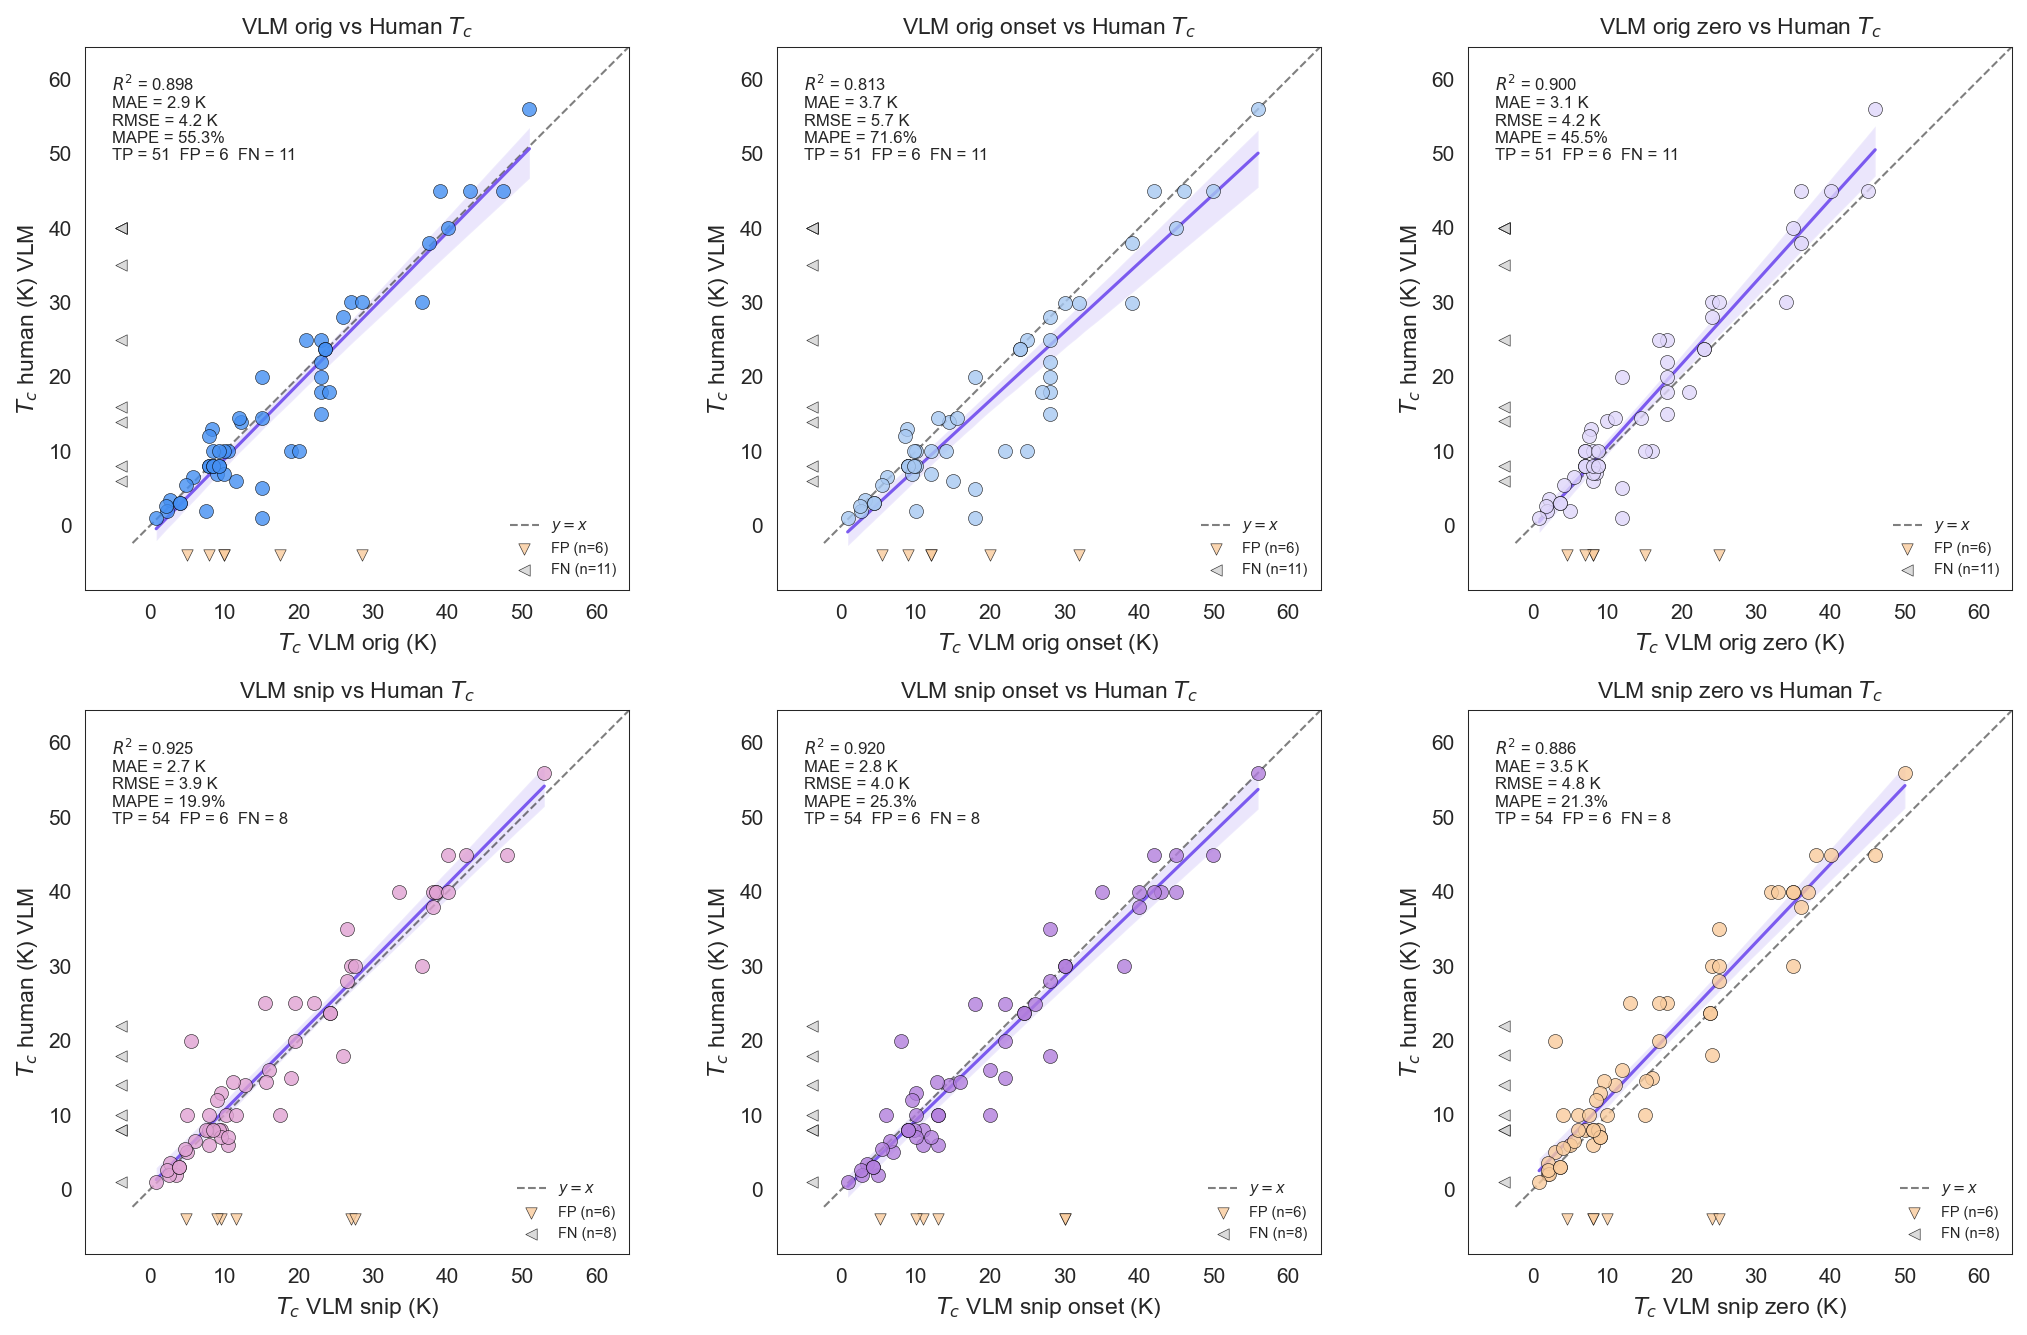


--- Tc_human (from plot) vs each VLM extraction ---
For each subplot:
  TP: Both VLM and human found a Tc value from the figure.
  FP: VLM extracted a Tc from the figure, but human says 'Not in plot' — false detection.
  FN: Human read a Tc from the figure, but VLM returned nothing — missed extraction.

  VLM orig              TP= 51   FP=  6   FN= 11
  VLM orig onset        TP= 51   FP=  6   FN= 11
  VLM orig zero         TP= 51   FP=  6   FN= 11
  VLM snip              TP= 54   FP=  6   FN=  8
  VLM snip onset        TP= 54   FP=  6   FN=  8
  VLM snip zero         TP= 54   FP=  6   FN=  8


In [9]:
vlm_cols = [
    ("tc_vlm_orig",       "VLM orig"),
    ("tc_vlm_orig_onset", "VLM orig onset"),
    ("tc_vlm_orig_zero",  "VLM orig zero"),
    ("tc_vlm_snip",       "VLM snip"),
    ("tc_vlm_snip_onset", "VLM snip onset"),
    ("tc_vlm_snip_zero",  "VLM snip zero"),
]

vlm_colors = [C_BLUE, C_LBLUE, C_LAVENDER, C_PINK, C_LPURPLE, C_ORANGE]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (col, label), color in zip(axes.flat, vlm_cols, vlm_colors):
    # FP: VLM extracted but human says "Not in plot"
    fp = df[col].notna() & df["plot_human_not_in_plot"]
    # FN: human has plot Tc but VLM missed
    fn = df[col].isna() & df["Tc_human_num"].notna()

    parity_plot(
        df[col], df["Tc_human_num"],
        xlabel=f"$T_c$ {label} (K)",
        ylabel="$T_c$ human (K) VLM",
        title=f"{label} vs Human $T_c$",
        ax=ax, color=color,
        fp_mask=fp, fp_vals=df[col],
        fn_mask=fn, fn_vals=df["Tc_human_num"],
    )

plt.tight_layout()
plt.show()

print("\n--- Tc_human (from plot) vs each VLM extraction ---")
print("For each subplot:")
print("  TP: Both VLM and human found a Tc value from the figure.")
print("  FP: VLM extracted a Tc from the figure, but human says 'Not in plot' — false detection.")
print("  FN: Human read a Tc from the figure, but VLM returned nothing — missed extraction.\n")
for col, label in vlm_cols:
    fp = df[col].notna() & df["plot_human_not_in_plot"]
    fn = df[col].isna() & df["Tc_human_num"].notna()
    tp = (df[col].notna() & df["Tc_human_num"].notna()).sum()
    print(f"  {label:20s}  TP={tp:3d}   FP={fp.sum():3d}   FN={fn.sum():3d}")

Actually compring with Human Tc text and not VLM 

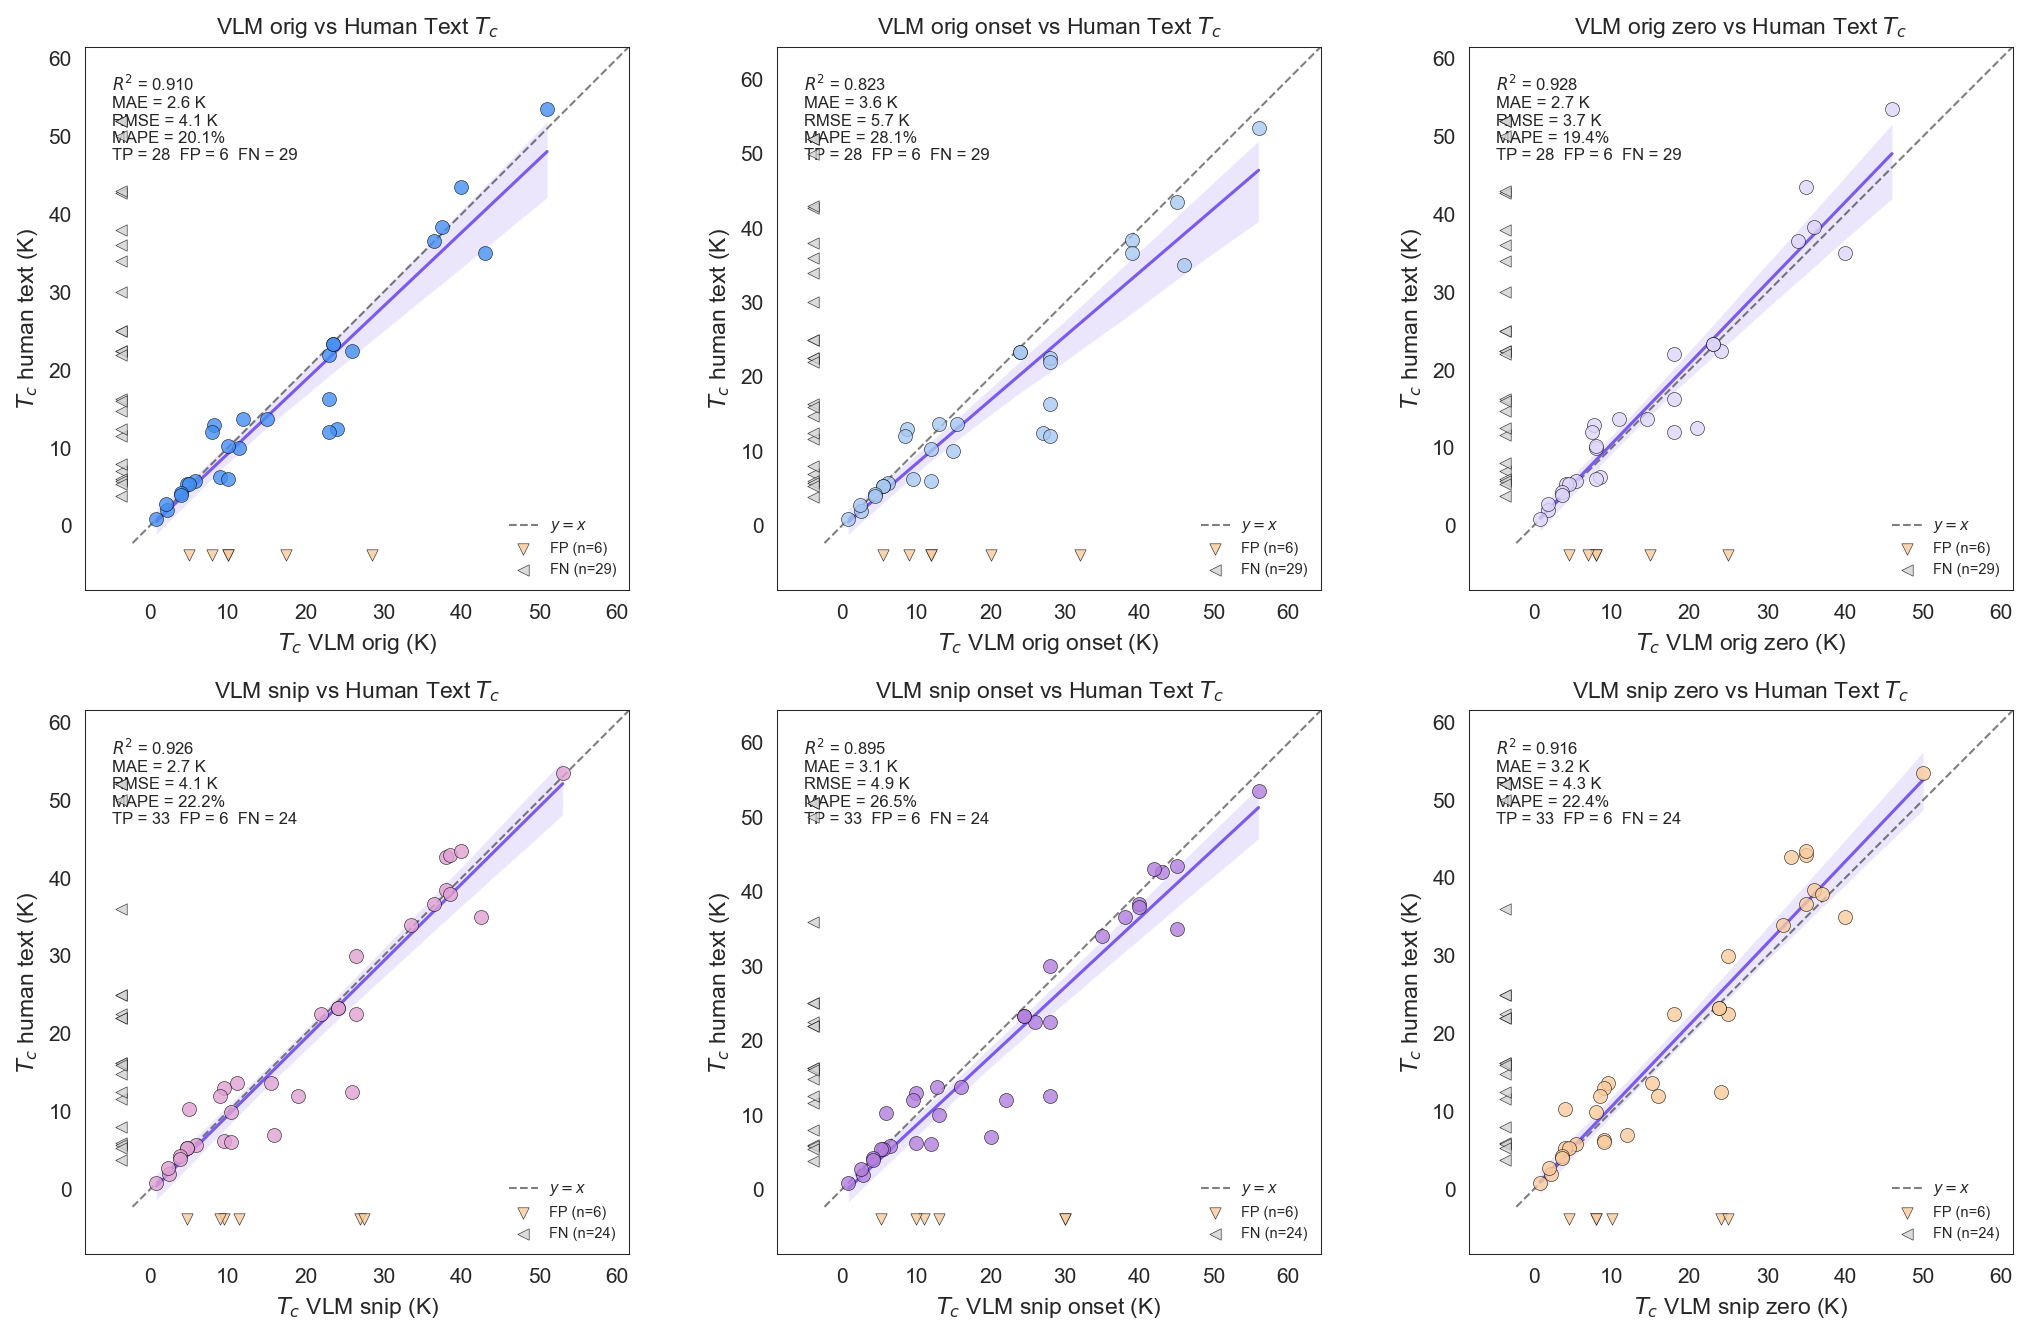


--- Tc_text_human (ground truth) vs each VLM extraction ---
For each subplot:
  TP: Both VLM and human text have a Tc value.
  FP: VLM extracted a Tc from the figure, but human says 'Not in plot' — false detection.
  FN: Human text Tc exists, but VLM returned nothing — missed extraction.

  VLM orig              TP= 27   FP=  6   FN= 29
  VLM orig onset        TP= 27   FP=  6   FN= 29
  VLM orig zero         TP= 27   FP=  6   FN= 29
  VLM snip              TP= 32   FP=  6   FN= 24
  VLM snip onset        TP= 32   FP=  6   FN= 24
  VLM snip zero         TP= 32   FP=  6   FN= 24


In [11]:
vlm_cols = [
    ("tc_vlm_orig",       "VLM orig"),
    ("tc_vlm_orig_onset", "VLM orig onset"),
    ("tc_vlm_orig_zero",  "VLM orig zero"),
    ("tc_vlm_snip",       "VLM snip"),
    ("tc_vlm_snip_onset", "VLM snip onset"),
    ("tc_vlm_snip_zero",  "VLM snip zero"),
]
vlm_colors = [C_BLUE, C_LBLUE, C_LAVENDER, C_PINK, C_LPURPLE, C_ORANGE]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (col, label), color in zip(axes.flat, vlm_cols, vlm_colors):
    # FP: VLM extracted but human says "Not in plot"
    fp = df[col].notna() & df["plot_human_not_in_plot"]
    # FN: human has text Tc but VLM missed
    fn = df[col].isna() & df["Tc_text_human"].notna()

    parity_plot(
        df[col], df["Tc_text_human"],
        xlabel=f"$T_c$ {label} (K)",
        ylabel="$T_c$ human text (K)",
        title=f"{label} vs Human Text $T_c$",
        ax=ax, color=color,
        fp_mask=fp, fp_vals=df[col],
        fn_mask=fn, fn_vals=df["Tc_text_human"],
    )

plt.tight_layout()
plt.show()

print("\n--- Tc_text_human (ground truth) vs each VLM extraction ---")
print("For each subplot:")
print("  TP: Both VLM and human text have a Tc value.")
print("  FP: VLM extracted a Tc from the figure, but human says 'Not in plot' — false detection.")
print("  FN: Human text Tc exists, but VLM returned nothing — missed extraction.\n")

for col, label in vlm_cols:
    fp = df[col].notna() & df["plot_human_not_in_plot"]
    fn = df[col].isna() & df["Tc_text_human"].notna()
    tp = (df[col].notna() & df["Tc_text_human"].notna() & ~fp).sum()
    print(f"  {label:20s}  TP={tp:3d}   FP={fp.sum():3d}   FN={fn.sum():3d}")


---
## 3 · Human Text Annotation vs Human Ground-Truth Tc

`Tc_text human` vs `Tc_human` — which materials appear in text only, plot only, or both?

- Points on parity: material has Tc in both text and plot
- **Text only** (along x-axis): human found Tc in text but says "Not in plot"
- **Plot only** (along y-axis): human found Tc in plot but says "Not written" in text

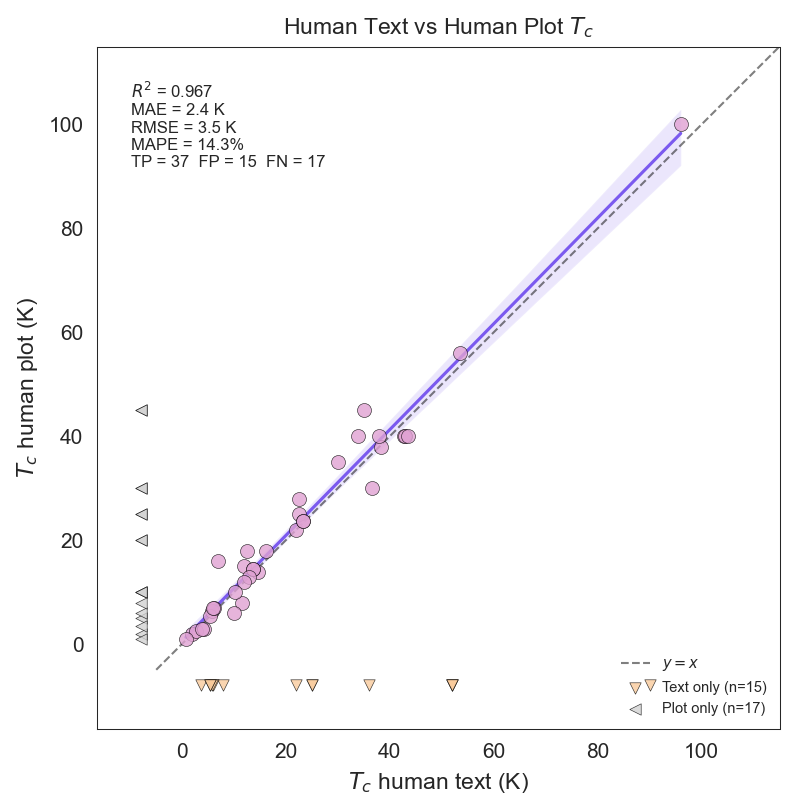


--- Human Text vs Human Plot ---
Both (37): Human found a Tc in both the text and the figure for this material.
Text only (15): Human found a Tc in the text, but says 'Not in plot' — value only reported in text.
Plot only (17): Human read a Tc from the figure, but says 'Not written' — value only visible in a figure.


In [15]:
# Text only: human has text Tc but says "Not in plot"
text_only = df["Tc_text_human"].notna() & df["plot_human_not_in_plot"]
# Plot only: human has plot Tc but says "Not written" in text
plot_only = df["Tc_human_num"].notna() & df["text_human_not_written"]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
parity_plot(
    df["Tc_text_human"], df["Tc_human_num"],
    xlabel="$T_c$ human text (K)",
    ylabel="$T_c$ human plot (K)",
    title="Human Text vs Human Plot $T_c$",
    ax=ax, color=C_PINK,
    fp_mask=text_only, fp_vals=df["Tc_text_human"],
    fn_mask=plot_only, fn_vals=df["Tc_human_num"],
)

# Relabel legend entries for this specific plot
handles, labels = ax.get_legend_handles_labels()
new_labels = []
for lbl in labels:
    if lbl.startswith("FP"):
        new_labels.append(lbl.replace("FP", "Text only"))
    elif lbl.startswith("FN"):
        new_labels.append(lbl.replace("FN", "Plot only"))
    else:
        new_labels.append(lbl)
ax.legend(handles, new_labels, fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

n_both = (df["Tc_text_human"].notna() & df["Tc_human_num"].notna()).sum()
print(f"\n--- Human Text vs Human Plot ---")
print(f"Both ({n_both}): Human found a Tc in both the text and the figure for this material.")
print(f"Text only ({text_only.sum()}): Human found a Tc in the text, but says 'Not in plot' — value only reported in text.")
print(f"Plot only ({plot_only.sum()}): Human read a Tc from the figure, but says 'Not written' — value only visible in a figure.")